## 0. Imports & shared utilities

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
import copy, time, gc, warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [ ]:
target_col = 'y_target'
time_col   = 'ts_index'
id_col     = 'id'
group_keys = ['code', 'sub_code', 'sub_category', 'horizon']


train_path = 'D:\\Projects\\Practical_DL\\Practical_DL\\Data\\train.parquet'
export_dir = 'D:\\Projects\\Practical_DL\\Practical_DL\\Data\\output\\feature_set_exports_m1_simple'


n_sample_groups = 1000   
seq_len         = 20     
val_frac        = 0.15  


epochs   = 40
patience = 6


best_a_hidden    = 64
best_a_layers    = 2
best_a_dropout   = 0.2
best_a_batch     = 128
best_a_lr        = 1e-3
best_a_optimizer = 'Adam'
best_a_scheduler = 'ReduceOnPlateau'

In [ ]:
results_log = []

#save one experiment run to the log
def log_run(run_id, block, feature_set, optimizer_name,
            lr, batch_size, epochs_run, val_mae, val_rmse, extra=''):
    results_log.append({
        'run_id':      run_id,
        'block':       block,
        'model':       'LSTM',
        'feature_set': feature_set,
        'optimizer':   optimizer_name,
        'lr':          lr,
        'batch_size':  batch_size,
        'epochs_run':  epochs_run,
        'val_mae':     val_mae,
        'val_rmse':    val_rmse,
        'extra':       extra,
    })

def show_log():
    df = pd.DataFrame(results_log)
    display(df)
    return df

In [ ]:
# LSTM model 
# input_size is set dynamically based on the feature set loaded.
# Everything else is configurable per experiment.

class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        out, _ = self.lstm(x)       # out: (batch, seq_len, hidden_size)
        last = out[:, -1, :]        # take last time step
        return self.head(last).squeeze(-1)


class TSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

In [ ]:
#This function converts a single time series into supervised learning samples using sliding windows
#data:(T, F)

def create_sequences(data: np.ndarray, seq_len: int):
    T, F = data.shape
    N = T - seq_len
    if N <= 0:
        return np.empty((0, seq_len, F), dtype=np.float32), np.empty((0,), dtype=np.float32)
    X = np.empty((N, seq_len, F), dtype=np.float32)
    y = np.empty((N,), dtype=np.float32)
    for i in range(N):
        X[i] = data[i : i + seq_len]    # (seq_len, F)
        y[i] = data[i + seq_len, 0]     # column 0 = y_target
    return X, y

In [ ]:
def load_feature_set(feat_path, n_sample=n_sample_group, seq_len=seq_len):
    meta_cols = [id_col, time_col, target_col] + group_keys
    df_meta = pd.read_parquet(train_path, columns=meta_cols)

    df_feats = pd.read_parquet(feat_path)
    feature_cols = [c for c in df_feats.columns
                    if c not in group_keys + [target_col, time_col, id_col, 'weight']]
    model_cols = [target_col] + feature_cols
    input_size = len(model_cols)


    assert len(df_meta) == len(df_feats), f'Row mismatch: {len(df_meta)} vs {len(df_feats)}'
    df = pd.concat([df_meta, df_feats[feature_cols]], axis=1)
    del df_meta, df_feats; gc.collect()
    print(f'  Loaded: {len(df):,} rows x {input_size} input channels ({len(feature_cols)} features)')

    
    unique_keys  = df[group_keys].drop_duplicates()
    sampled_keys = unique_keys.sample(n=min(n_sample, len(unique_keys)), random_state=SEED)
    df = df.merge(sampled_keys, on=group_keys, how='inner')
    print(f'  Sampled {len(sampled_keys)} groups -> {len(df):,} rows')

    
    group_train, group_val = {}, {}
    for name, gdf in df.groupby(group_keys, sort=False):
        gdf = gdf.sort_values(time_col)
        gdf[model_cols] = gdf[model_cols].ffill().bfill().fillna(0.0)
        vals = gdf[model_cols].values.astype(np.float32)
        if len(vals) < seq_len + 1:
            continue
        split = int(len(vals) * (1 - VAL_FRAC))
        group_train[name] = vals[:split]
        group_val[name]   = vals[split:]

    
    all_train = np.concatenate(list(group_train.values()))
    scaler = RobustScaler().fit(all_train)
    del all_train; gc.collect()


    def _make_seqs(groups):
        Xs, ys = [], []
        for vals in groups.values():
            scaled = scaler.transform(vals).astype(np.float32)
            X, y = create_sequences(scaled, seq_len)
            if len(X) > 0:
                Xs.append(X)
                ys.append(y)
        if not Xs:
            return np.empty((0, seq_len, input_size), dtype=np.float32), np.empty((0,), dtype=np.float32)
        return np.concatenate(Xs), np.concatenate(ys)

    X_tr, y_tr = _make_seqs(group_train)
    X_va, y_va = _make_seqs(group_val)
    del df, group_train, group_val; gc.collect()

    print(f'  Train: {len(X_tr):,} | Val: {len(X_va):,} | input_size: {input_size}')
    return X_tr, y_tr, X_va, y_va, input_size

In [ ]:

def make_optimizer(name, params, lr, weight_decay=1e-5):
    if name == 'Adam':    return torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)
    if name == 'SGD':     return torch.optim.SGD(params, lr=lr, weight_decay=weight_decay, momentum=0.9)
    if name == 'RMSProp': return torch.optim.RMSprop(params, lr=lr, weight_decay=weight_decay)
    raise ValueError(f'Unknown optimizer: {name}')


def make_scheduler(name, optimizer):
    if name == 'ReduceOnPlateau': return torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=3)
    if name == 'StepLR':          return torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    if name == 'CosineAnnealing': return torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    if name == 'None':            return None
    raise ValueError(f'Unknown scheduler: {name}')


def train_and_eval(model, train_loader, val_loader,
                   optimizer_name='Adam', lr=1e-3,
                   scheduler_name='ReduceOnPlateau',
                   patience=PATIENCE, epochs=EPOCHS,
                   save_path='best_exp.pt'):
    criterion = nn.HuberLoss(delta=1.0)
    optimizer = make_optimizer(optimizer_name, model.parameters(), lr)
    scheduler = make_scheduler(scheduler_name, optimizer)

    best_val_loss = float('inf')
    best_mae = best_rmse = float('inf')
    patience_ctr = 0
    history = {'train': [], 'val': [], 'mae': []}
    epoch_run = 0

    for epoch in range(1, epochs + 1):
        # ── Train ──
        model.train()
        t_loss, n = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            t_loss += loss.item() * len(yb); n += len(yb)
        train_loss = t_loss / n

        # ── Validate ──
        model.eval()
        v_loss, n = 0.0, 0
        preds_all, tgts_all = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                p = model(xb)
                v_loss += criterion(p, yb).item() * len(yb); n += len(yb)
                preds_all.append(p.cpu()); tgts_all.append(yb.cpu())
        val_loss = v_loss / n
        p_cat = torch.cat(preds_all); t_cat = torch.cat(tgts_all)
        val_mae  = torch.mean(torch.abs(p_cat - t_cat)).item()
        val_rmse = torch.sqrt(torch.mean((p_cat - t_cat) ** 2)).item()

        # ── Scheduler ──
        if scheduler is not None:
            if scheduler_name == 'ReduceOnPlateau': scheduler.step(val_loss)
            else: scheduler.step()

        history['train'].append(train_loss)
        history['val'].append(val_loss)
        history['mae'].append(val_mae)
        epoch_run = epoch

        # ── Checkpoint ──
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_mae  = val_mae
            best_rmse = val_rmse
            patience_ctr = 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_ctr += 1

        if epoch % 5 == 0 or patience_ctr >= patience:
            print(f'  ep {epoch:3d} | train={train_loss:.5f} val={val_loss:.5f} MAE={val_mae:.5f}')

        if patience_ctr >= patience:
            print(f'  -> Early stop at epoch {epoch}')
            break

    return best_mae, best_rmse, epoch_run, history


def plot_history(history, title):
    """Two-panel plot: Huber loss + val MAE."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    axes[0].plot(history['train'], label='train'); axes[0].plot(history['val'], label='val')
    axes[0].set_title(f'{title} — Huber loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(history['mae'], color='orange', label='val MAE')
    axes[1].set_title(f'{title} — Val MAE'); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

In [ ]:
FEATURE_SETS = {
    'set_global_core':    f'{export_dir}/set_global_core.parquet',
    'set_global_uncorr':  f'{export_dir}/set_global_uncorr.parquet',
    'set_global_support': f'{export_dir}/set_global_support.parquet',
}

=== B1: set_global_core (10 features) ===
  Loaded: 5,337,414 rows x 11 input channels (10 features)
  Sampled 1000 groups -> 140,712 rows
  Train: 99,461 | Val: 4,717 | input_size: 11
  ep   5 | train=27.51109 val=32.59133 MAE=32.90229
  ep  10 | train=24.91605 val=31.73833 MAE=32.06545
  ep  15 | train=25.03064 val=31.44610 MAE=31.75760
  ep  18 | train=23.49044 val=31.13638 MAE=31.44684
  -> Early stop at epoch 18


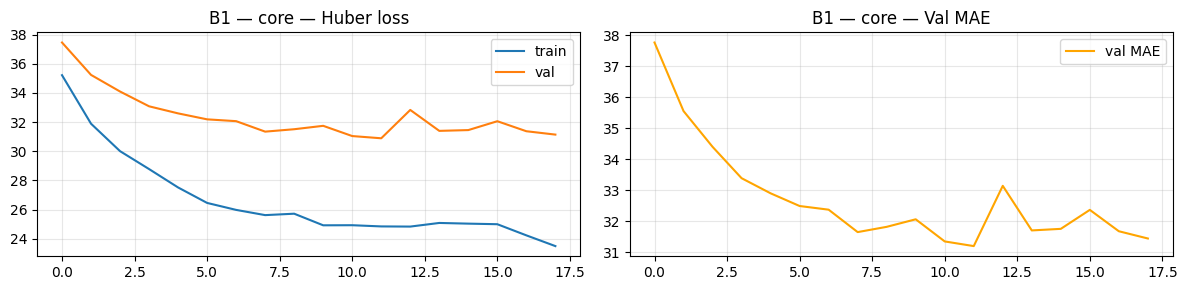

10829

In [ ]:
X_tr, y_tr, X_va, y_va, in_sz = load_feature_set(feature_sets['set_global_core'])

model_b1 = LSTMForecaster(input_size=in_sz, hidden_size=best_a_hidden,
    num_layers=best_a_layers, dropout=best_a_dropout).to(device)

tr_l = DataLoader(TSDataset(X_tr, y_tr), batch_size=best_a_batch, shuffle=True, num_workers=0)
va_l = DataLoader(TSDataset(X_va, y_va), batch_size=best_a_batch, shuffle=False, num_workers=0)

mae, rmse, ep, hist = train_and_eval(model_b1, tr_l, va_l,
    optimizer_name=best_a_optimizer, lr=best_a_lr,
    scheduler_name=best_a_scheduler, save_path='best_B1.pt')
plot_history(hist, 'B1 — core')
log_run('B1-core', 'B', 'set_global_core', best_a_optimizer,
        best_a_lr, best_a_batch, ep, mae, rmse, 'B1-feature_set')
del X_tr, y_tr, X_va, y_va; gc.collect()

=== B2: set_global_uncorr (16 features) ===
  Loaded: 5,337,414 rows x 17 input channels (16 features)
  Sampled 1000 groups -> 140,712 rows
  Train: 99,461 | Val: 4,717 | input_size: 17
  ep   5 | train=27.74055 val=32.10793 MAE=32.42193
  ep  10 | train=25.33823 val=30.45358 MAE=30.76747
  ep  15 | train=23.81747 val=31.18404 MAE=31.49785
  ep  20 | train=22.93040 val=30.11129 MAE=30.42215
  ep  25 | train=22.68019 val=29.97650 MAE=30.29049
  ep  30 | train=22.17426 val=30.17594 MAE=30.48880
  ep  31 | train=22.19620 val=30.34113 MAE=30.65536
  -> Early stop at epoch 31


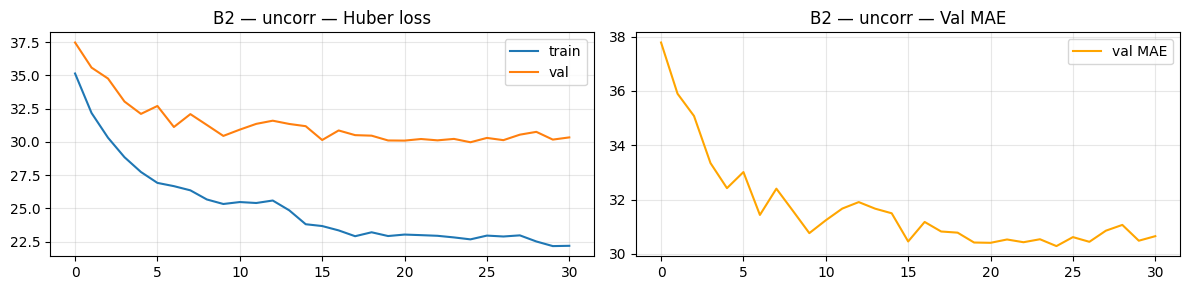

8317

In [ ]:
print('=== B2: set_global_uncorr (16 features) ===')
X_tr, y_tr, X_va, y_va, in_sz = load_feature_set(feature_sets['set_global_uncorr'])

model_b2 = LSTMForecaster(input_size=in_sz, hidden_size=best_a_hidden,
    num_layers=best_a_layers, dropout=best_a_dropout).to(device)

tr_l = DataLoader(TSDataset(X_tr, y_tr), batch_size=best_a_batch, shuffle=True, num_workers=0)
va_l = DataLoader(TSDataset(X_va, y_va), batch_size=best_a_batch, shuffle=False, num_workers=0)

mae, rmse, ep, hist = train_and_eval(model_b2, tr_l, va_l,
    optimizer_name=best_a_optimizer, lr=best_a_lr,
    scheduler_name=best_a_scheduler, save_path='best_B2.pt')
plot_history(hist, 'B2 — uncorr')
log_run('B2-uncorr', 'B', 'set_global_uncorr', best_a_optimizer,
        best_a_lr, best_a_batch, ep, mae, rmse, 'B2-feature_set')
del X_tr, y_tr, X_va, y_va; gc.collect()

=== B3: set_global_support (20 features) ===
  Loaded: 5,337,414 rows x 21 input channels (20 features)
  Sampled 1000 groups -> 140,712 rows
  Train: 99,461 | Val: 4,717 | input_size: 21
  ep   5 | train=27.74015 val=33.13128 MAE=33.44535
  ep  10 | train=25.15217 val=31.33854 MAE=31.65007
  ep  15 | train=24.87360 val=31.30043 MAE=31.61493
  ep  20 | train=24.68699 val=32.23653 MAE=32.54831
  ep  25 | train=22.82557 val=30.52811 MAE=30.83903
  ep  28 | train=22.10814 val=30.47465 MAE=30.78303
  -> Early stop at epoch 28


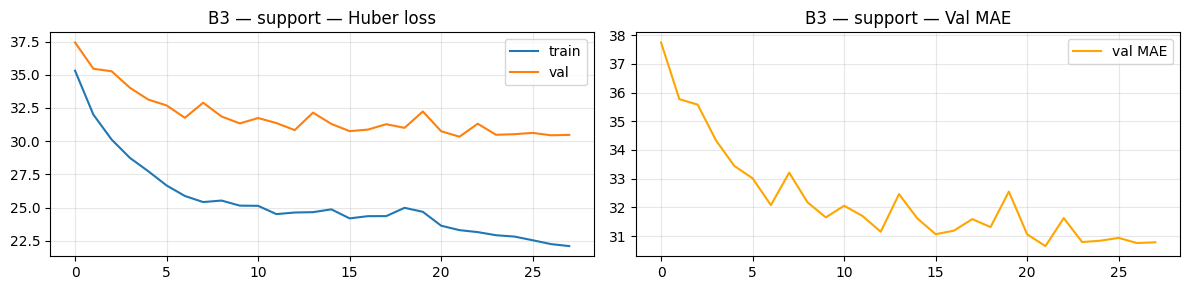

8471

In [ ]:
X_tr, y_tr, X_va, y_va, in_sz = load_feature_set(feature_sets['set_global_support'])

model_b3 = LSTMForecaster(input_size=in_sz, hidden_size=best_a_hidden,
    num_layers=best_a_layers, dropout=best_a_dropout).to(device)

tr_l = DataLoader(TSDataset(X_tr, y_tr), batch_size=best_a_batch, shuffle=True, num_workers=0)
va_l = DataLoader(TSDataset(X_va, y_va), batch_size=best_a_batch, shuffle=False, num_workers=0)

mae, rmse, ep, hist = train_and_eval(model_b3, tr_l, va_l,
    optimizer_name=best_a_optimizer, lr=best_a_lr,
    scheduler_name=best_a_scheduler, save_path='best_B3.pt')
plot_history(hist, 'B3 — support')
log_run('B3-support', 'B', 'set_global_support', best_a_optimizer,
        best_a_lr, best_a_batch, ep, mae, rmse, 'B3-feature_set')
del X_tr, y_tr, X_va, y_va; gc.collect()

In [ ]:
df_log = show_log()
block_b = df_log[df_log['block'] == 'B'].sort_values('val_mae')

best_b_feature_set = block_b.iloc[0]['feature_set']
BEST_B_FILE = FEATURE_SETS[best_b_feature_set]
print(f'\n-> Best feature set: {best_b_feature_set}  (MAE={block_b.iloc[0]["val_mae"]:.5f})')
print(f'   Carried forward to Block C.')

# Reload best feature set for remaining experiments
X_train_best, y_train_best, X_val_best, y_val_best, INPUT_SIZE_BEST = load_feature_set(BEST_B_FILE)

,run_id,block,model,feature_set,optimizer,lr,batch_size,epochs_run,val_mae,val_rmse,extra
0,B1-core,B,LSTM,set_global_core,Adam,0.001,128,18,31.202137,182.312332,B1-feature_set
1,B2-uncorr,B,LSTM,set_global_uncorr,Adam,0.001,128,31,30.290491,174.800430,B2-feature_set
2,B3-support,B,LSTM,set_global_support,Adam,0.001,128,28,30.650831,177.125397,B3-feature_set



-> Best feature set: set_global_uncorr  (MAE=30.29049)
   Carried forward to Block C.
  Loaded: 5,337,414 rows x 17 input channels (16 features)
  Sampled 1000 groups -> 140,712 rows
  Train: 99,461 | Val: 4,717 | input_size: 17


In [ ]:
#make DataLoaders from the best feature set
def make_loaders(X_tr, y_tr, X_va, y_va, batch_size):
    tr = DataLoader(TSDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
    va = DataLoader(TSDataset(X_va, y_va), batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    return tr, va

# creates a fresh model with Block A defaults + best input_size
def fresh_model():
    torch.manual_seed(SEED)
    return LSTMForecaster(
        input_size  = input_size_best,
        hidden_size = best_a_hidden,
        num_layers  = best_a_layers,
        dropout     = best_a_dropout,
    ).to(device)

=== C1: Optimizer ===

-- SGD --
  ep   5 | train=36.62004 val=40.39161 MAE=40.72538
  ep  10 | train=35.38415 val=39.45257 MAE=39.77327
  ep  15 | train=34.77105 val=38.88160 MAE=39.19720
  ep  20 | train=34.35981 val=38.43209 MAE=38.74783
  ep  25 | train=34.01036 val=38.48256 MAE=38.79693
  ep  30 | train=33.61831 val=38.15332 MAE=38.46787
  ep  35 | train=33.38930 val=37.61625 MAE=37.92883
  ep  40 | train=33.22909 val=37.42509 MAE=37.73631


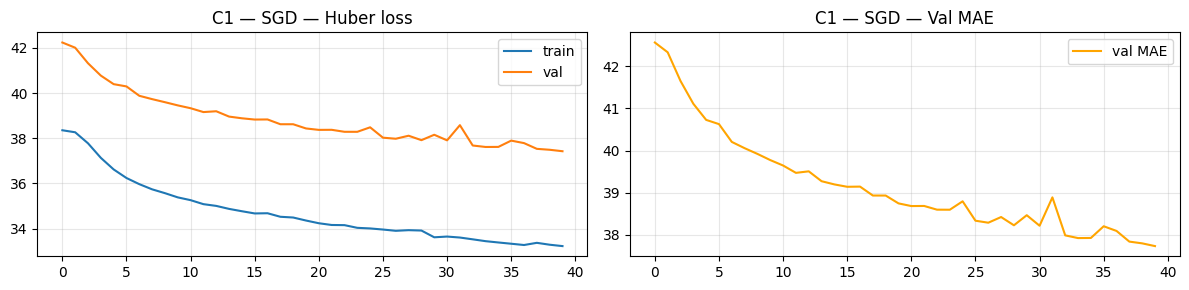


-- Adam --
  ep   5 | train=27.44875 val=32.79480 MAE=33.14489
  ep  10 | train=26.16740 val=31.96593 MAE=32.27882
  ep  15 | train=23.58119 val=30.59528 MAE=30.90580
  ep  20 | train=23.02665 val=30.79344 MAE=31.10272
  ep  25 | train=23.00537 val=30.02191 MAE=30.33028
  ep  30 | train=22.07638 val=30.12498 MAE=30.43347
  ep  31 | train=21.92590 val=30.21035 MAE=30.51857
  -> Early stop at epoch 31


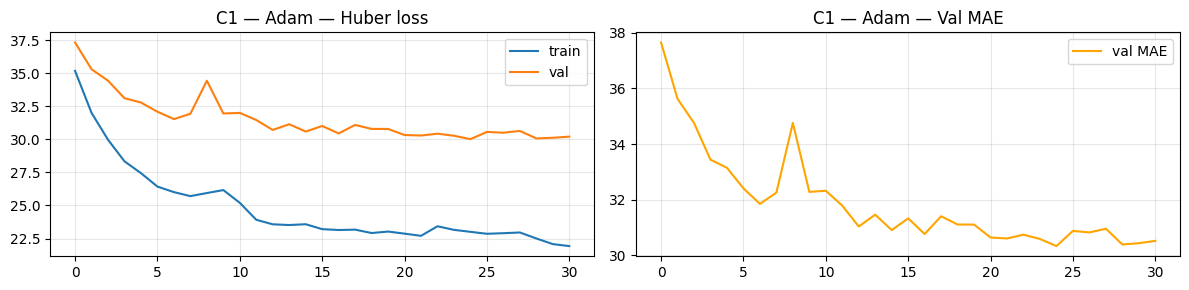


-- RMSProp --
  ep   5 | train=25.50800 val=38.11713 MAE=38.60186
  ep  10 | train=22.78327 val=30.36397 MAE=30.67185
  ep  15 | train=22.64170 val=31.03813 MAE=31.40532
  ep  20 | train=21.93283 val=30.38422 MAE=30.69461
  ep  25 | train=21.70251 val=29.19830 MAE=29.50634
  ep  29 | train=21.43820 val=29.88316 MAE=30.20553
  -> Early stop at epoch 29


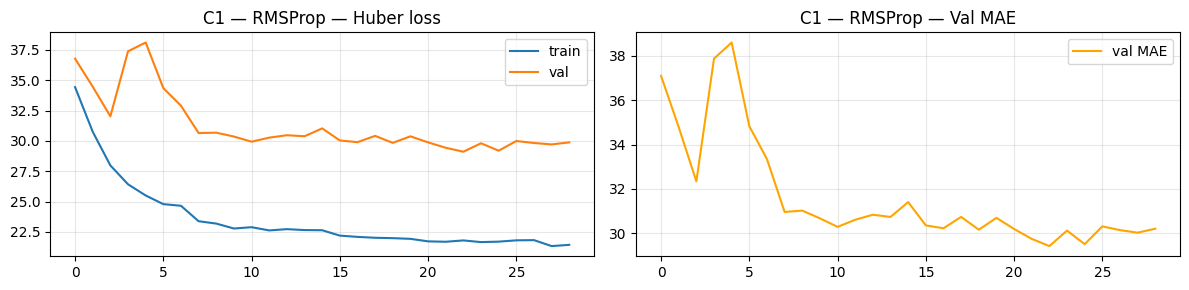

In [ ]:

tr_l, va_l = make_loaders(X_train_best, y_train_best, X_val_best, y_val_best, best_a_batch)

for opt_name in ['SGD', 'Adam', 'RMSProp']:
    print(f'\n-- {opt_name} --')
    m = fresh_model()
    mae, rmse, ep, hist = train_and_eval(m, tr_l, va_l,
        optimizer_name=opt_name, lr=best_a_lr,
        scheduler_name=best_a_scheduler, save_path=f'best_C1_{opt_name}.pt')
    plot_history(hist, f'C1 — {opt_name}')
    log_run(f'C1-{opt_name}', 'C', best_b_feature_set, opt_name,
            best_a_lr, best_a_batch, ep, mae, rmse, 'C1-optimizer')

In [ ]:
df_c1 = pd.DataFrame(results_log)
df_c1 = df_c1[df_c1['extra'] == 'C1-optimizer'].sort_values('val_mae')
display(df_c1[['run_id', 'optimizer', 'val_mae', 'val_rmse', 'epochs_run']])
best_c1_optimizer = df_c1.iloc[0]['optimizer']
print(f'\n-> Best optimizer: {best_c1_optimizer}')

,run_id,optimizer,val_mae,val_rmse,epochs_run
5,C1-RMSProp,RMSProp,29.420172,172.583374,29
4,C1-Adam,Adam,30.330282,174.937408,31
3,C1-SGD,SGD,37.736313,231.302628,40



-> Best optimizer: RMSProp


=== C2: Learning rate ===

-- lr=0.0001 --
  ep   5 | train=34.89869 val=38.70340 MAE=39.01292
  ep  10 | train=32.45965 val=36.61119 MAE=36.91967
  ep  15 | train=30.37597 val=35.22943 MAE=35.53856
  ep  20 | train=28.61125 val=33.96631 MAE=34.27617
  ep  25 | train=27.16421 val=32.73104 MAE=33.03884
  ep  30 | train=25.97482 val=32.28062 MAE=32.59710
  ep  35 | train=25.14508 val=31.76281 MAE=32.07211
  ep  40 | train=24.41395 val=31.53407 MAE=31.84075
  -> Early stop at epoch 40


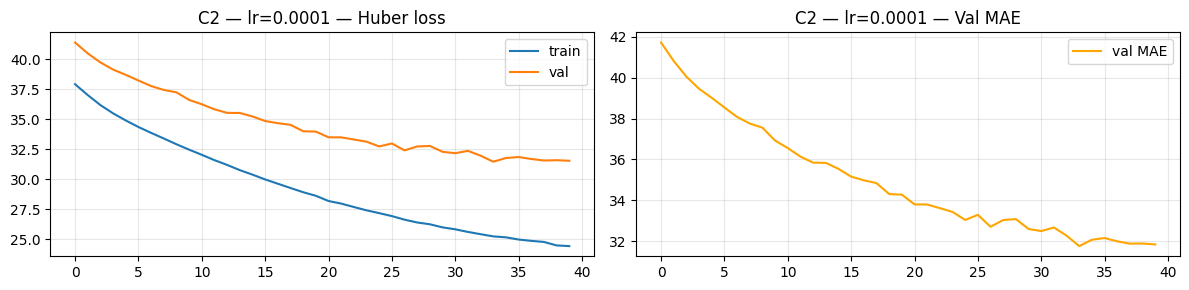


-- lr=0.001 --
  ep   5 | train=25.50800 val=38.11713 MAE=38.60186
  ep  10 | train=22.78327 val=30.36397 MAE=30.67185
  ep  15 | train=22.64170 val=31.03813 MAE=31.40532
  ep  20 | train=21.93283 val=30.38422 MAE=30.69461
  ep  25 | train=21.70251 val=29.19830 MAE=29.50634
  ep  29 | train=21.43820 val=29.88316 MAE=30.20553
  -> Early stop at epoch 29


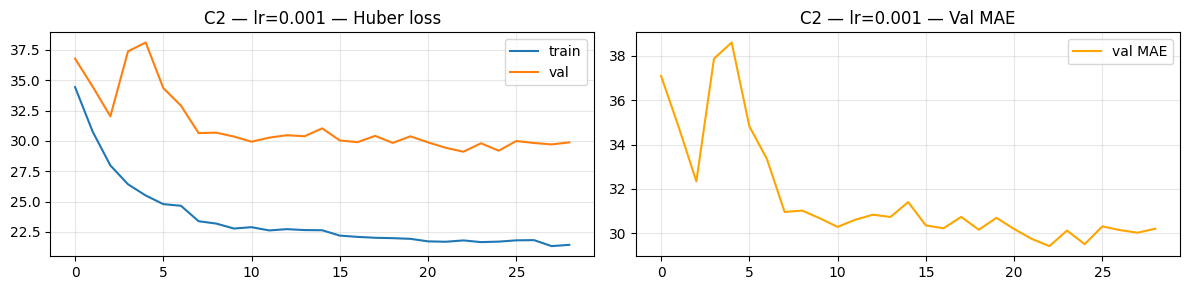


-- lr=0.01 --
  ep   5 | train=28.94746 val=34.76020 MAE=35.09850
  ep  10 | train=29.23469 val=35.96762 MAE=36.28127
  ep  15 | train=28.57662 val=37.64647 MAE=38.12257
  ep  20 | train=27.28412 val=32.68643 MAE=33.00803
  ep  25 | train=26.97713 val=31.98587 MAE=32.30247
  ep  27 | train=25.85721 val=31.71966 MAE=32.03032
  -> Early stop at epoch 27


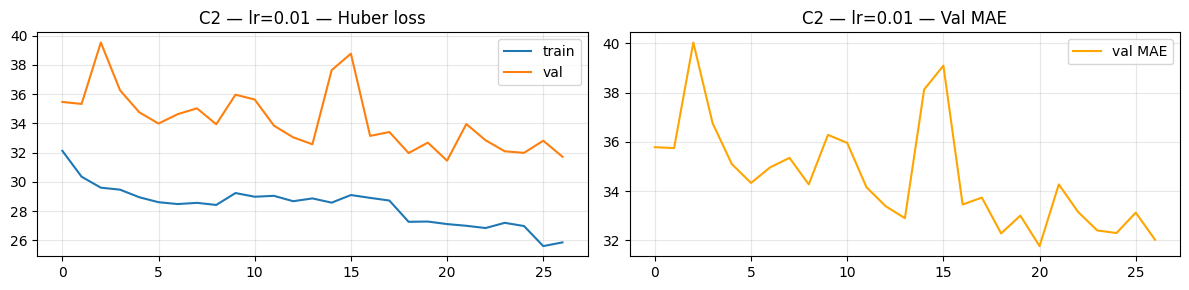

In [ ]:
for lr in [1e-4, 1e-3, 1e-2]:
    print(f'\n-- lr={lr} --')
    m = fresh_model()
    mae, rmse, ep, hist = train_and_eval(m, tr_l, va_l,
        optimizer_name=best_c1_optimizer, lr=lr,
        scheduler_name=best_a_scheduler, save_path=f'best_C2_lr{lr}.pt')
    plot_history(hist, f'C2 — lr={lr}')
    log_run(f'C2-lr{lr}', 'C', best_b_feature_set, best_c1_optimizer,
            lr, best_a_batch, ep, mae, rmse, 'C2-lr')

In [36]:
df_c2 = pd.DataFrame(results_log)
df_c2 = df_c2[df_c2['extra'] == 'C2-lr'].sort_values('val_mae')
display(df_c2[['run_id', 'lr', 'val_mae', 'val_rmse', 'epochs_run']])
BEST_C2_LR = df_c2.iloc[0]['lr']
print(f'\n-> Best LR: {BEST_C2_LR}')

,run_id,lr,val_mae,val_rmse,epochs_run
7,C2-lr0.001,0.0010,29.420172,172.583374,29
6,C2-lr0.0001,0.0001,31.760750,197.338882,40
8,C2-lr0.01,0.0100,31.772163,186.667267,27



-> Best LR: 0.001


=== C3: Batch size ===

-- batch_size=32 --
  ep   5 | train=26.11596 val=32.03268 MAE=32.38926
  ep  10 | train=25.55145 val=32.41275 MAE=32.71986
  ep  15 | train=23.67276 val=31.75320 MAE=32.05917
  ep  18 | train=22.99166 val=31.49727 MAE=31.80245
  -> Early stop at epoch 18


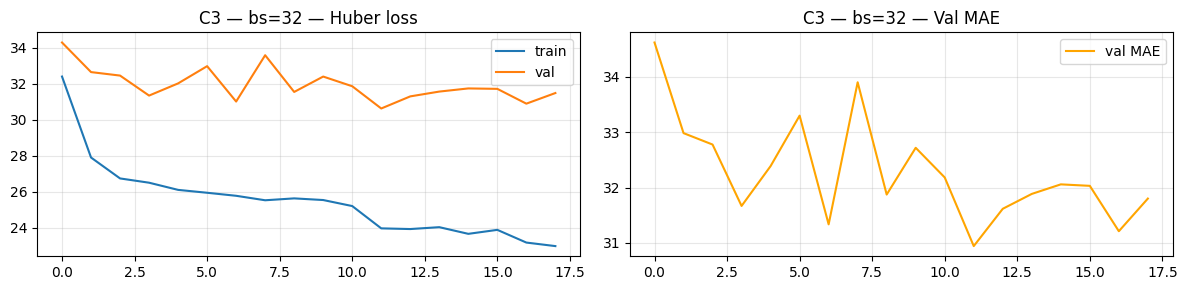


-- batch_size=64 --
  ep   5 | train=25.82674 val=32.64744 MAE=33.12027
  ep  10 | train=23.28554 val=30.34808 MAE=30.65531
  ep  15 | train=22.52412 val=30.10245 MAE=30.41365
  ep  20 | train=21.79350 val=30.31098 MAE=30.61992
  ep  25 | train=21.54371 val=29.91599 MAE=30.22239
  ep  27 | train=21.37189 val=30.02219 MAE=30.32972
  -> Early stop at epoch 27


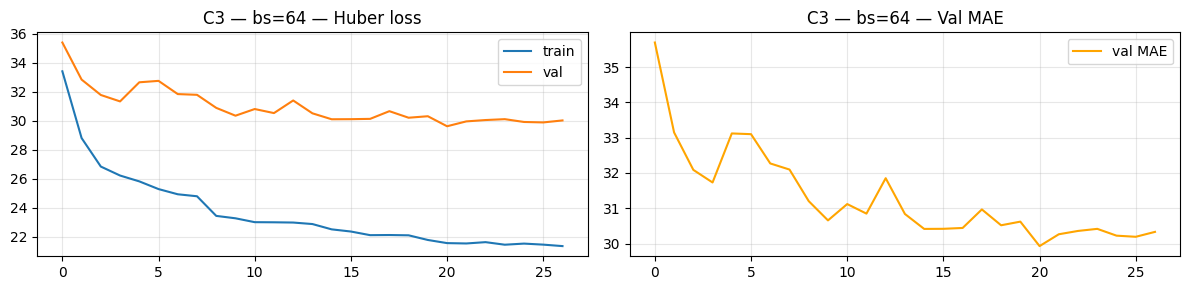


-- batch_size=128 --
  ep   5 | train=25.50800 val=38.11713 MAE=38.60186
  ep  10 | train=22.78327 val=30.36397 MAE=30.67185
  ep  15 | train=22.64170 val=31.03813 MAE=31.40532
  ep  20 | train=21.93283 val=30.38422 MAE=30.69461
  ep  25 | train=21.70251 val=29.19830 MAE=29.50634
  ep  29 | train=21.43820 val=29.88316 MAE=30.20553
  -> Early stop at epoch 29


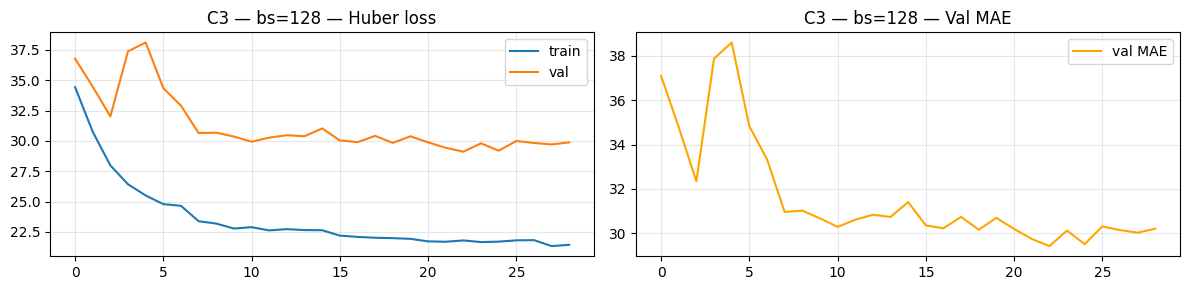

In [ ]:

for bs in [32, 64, 128]:
    print(f'\n-- batch_size={bs} --')
    tr_l, va_l = make_loaders(X_train_best, y_train_best, X_val_best, y_val_best, bs)
    m = fresh_model()
    mae, rmse, ep, hist = train_and_eval(m, tr_l, va_l,
        optimizer_name=best_c1_optimizer, lr=best_c2_lr,
        scheduler_name=best_a_scheduler, save_path=f'best_C3_bs{bs}.pt')
    plot_history(hist, f'C3 — bs={bs}')
    log_run(f'C3-bs{bs}', 'C', best_b_feature_set, best_c1_optimizer,
            best_c2_lr, bs, ep, mae, rmse, 'C3-batch')

In [ ]:
df_c3 = pd.DataFrame(results_log)
df_c3 = df_c3[df_c3['extra'] == 'C3-batch'].sort_values('val_mae')
display(df_c3[['run_id', 'batch_size', 'val_mae', 'val_rmse', 'epochs_run']])
best_c3_batch = int(df_c3.iloc[0]['batch_size'])
print(f'\n-> Best batch size: {best_c3_batch}')

,run_id,batch_size,val_mae,val_rmse,epochs_run
11,C3-bs128,128,29.420172,172.583374,29
10,C3-bs64,64,29.926470,175.551056,27
9,C3-bs32,32,30.943502,184.600296,18



-> Best batch size: 128


=== C4: LR Scheduler ===

-- scheduler=StepLR --
  ep   5 | train=25.50800 val=38.11713 MAE=38.60186
  ep   9 | train=24.51359 val=32.66882 MAE=33.00095
  -> Early stop at epoch 9


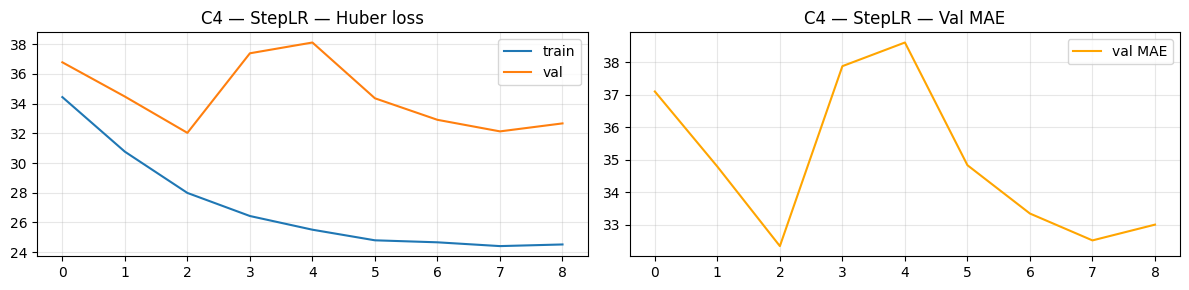


-- scheduler=CosineAnnealing --
  ep   5 | train=25.70466 val=36.71301 MAE=37.18462
  ep  10 | train=23.90368 val=30.17023 MAE=30.47874
  ep  15 | train=23.35995 val=31.88876 MAE=32.35954
  ep  16 | train=22.97368 val=30.79996 MAE=31.10790
  -> Early stop at epoch 16


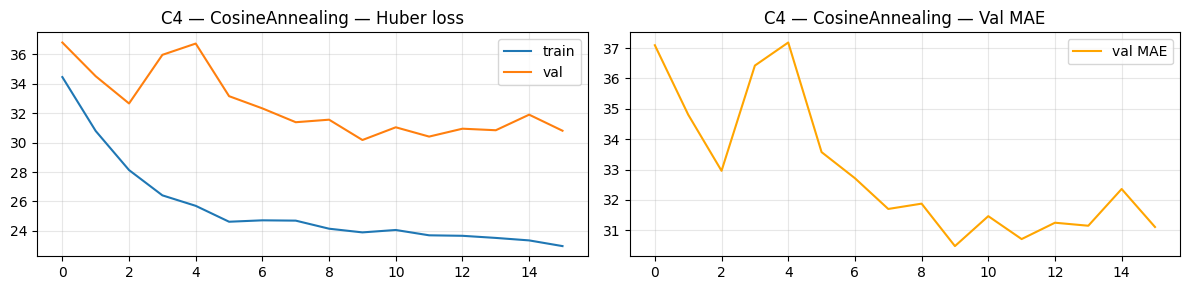


-- scheduler=ReduceOnPlateau --
  ep   5 | train=25.50800 val=38.11713 MAE=38.60186
  ep  10 | train=22.78327 val=30.36397 MAE=30.67185
  ep  15 | train=22.64170 val=31.03813 MAE=31.40532
  ep  20 | train=21.93283 val=30.38422 MAE=30.69461
  ep  25 | train=21.70251 val=29.19830 MAE=29.50634
  ep  29 | train=21.43820 val=29.88316 MAE=30.20553
  -> Early stop at epoch 29


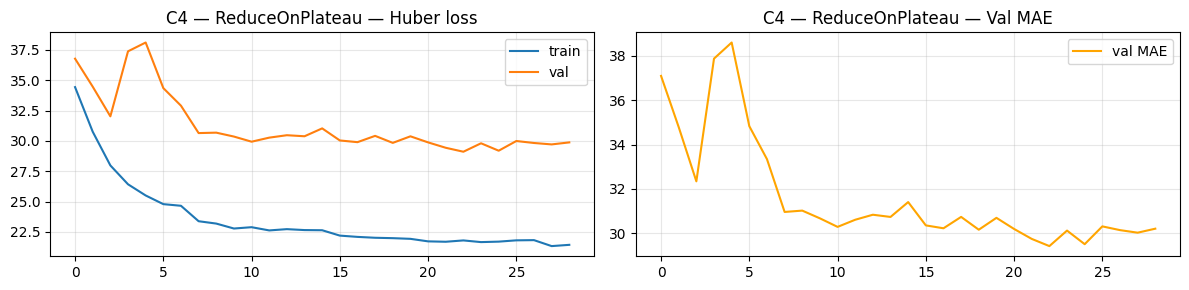

In [ ]:
tr_l, va_l = make_loaders(X_train_best, y_train_best, X_val_best, y_val_best, best_c3_batch)
for sched in ['StepLR', 'CosineAnnealing', 'ReduceOnPlateau']:
    print(f'\n-- scheduler={sched} --')
    m = fresh_model()
    mae, rmse, ep, hist = train_and_eval(m, tr_l, va_l,
        optimizer_name=best_c1_optimizer, lr=best_c2_lr,
        scheduler_name=sched, save_path=f'best_C4_{sched}.pt')
    plot_history(hist, f'C4 — {sched}')
    log_run(f'C4-{sched}', 'C', best_b_feature_set, best_c1_optimizer,
            best_c2_lr, best_c3_batch, ep, mae, rmse, 'C4-scheduler')

In [ ]:
df_c4 = pd.DataFrame(results_log)
df_c4 = df_c4[df_c4['extra'] == 'C4-scheduler'].sort_values('val_mae')
display(df_c4[['run_id', 'val_mae', 'val_rmse', 'epochs_run']])
best_c4_scheduler = df_c4.iloc[0]['run_id'].replace('C4-', '')
print(f'\n-> Best scheduler: {best_c4_scheduler}')

,run_id,val_mae,val_rmse,epochs_run
14,C4-ReduceOnPlateau,29.420172,172.583374,29
13,C4-CosineAnnealing,30.478741,177.844193,16
12,C4-StepLR,32.340714,200.485535,9



-> Best scheduler: ReduceOnPlateau


=== C5: Early stopping patience ===

-- patience=5 --
  ep   5 | train=25.50800 val=38.11713 MAE=38.60186
  ep  10 | train=22.78327 val=30.36397 MAE=30.67185
  ep  15 | train=22.64170 val=31.03813 MAE=31.40532
  ep  16 | train=22.19921 val=30.04338 MAE=30.35405
  -> Early stop at epoch 16


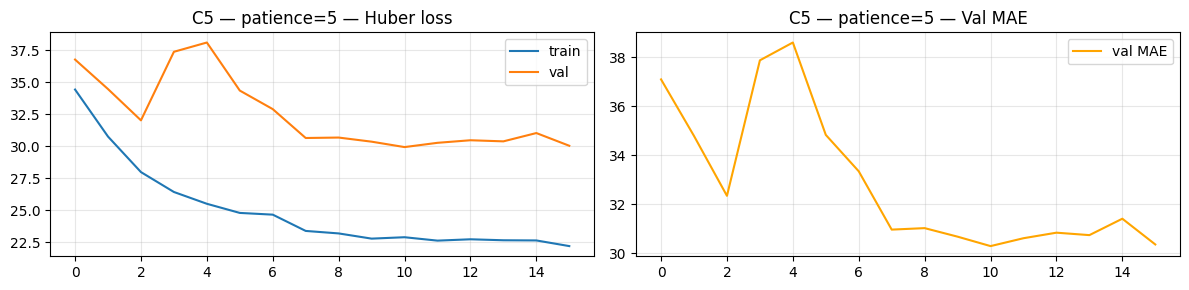


-- patience=10 --
  ep   5 | train=25.50800 val=38.11713 MAE=38.60186
  ep  10 | train=22.78327 val=30.36397 MAE=30.67185
  ep  15 | train=22.64170 val=31.03813 MAE=31.40532
  ep  20 | train=21.93283 val=30.38422 MAE=30.69461
  ep  25 | train=21.70251 val=29.19830 MAE=29.50634
  ep  30 | train=21.36272 val=29.41324 MAE=29.72668
  ep  33 | train=21.09447 val=29.41430 MAE=29.72065
  -> Early stop at epoch 33


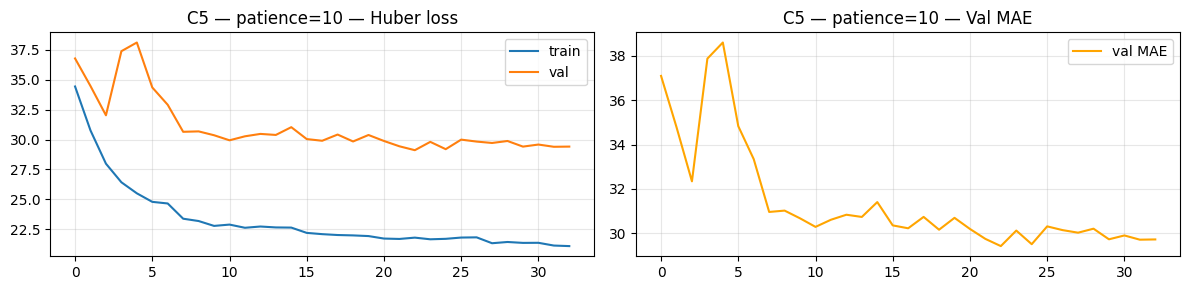

In [ ]:
for pat in [5, 10]:
    print(f'\n-- patience={pat} --')
    m = fresh_model()
    mae, rmse, ep, hist = train_and_eval(m, tr_l, va_l,
        optimizer_name=best_c1_optimizer, lr=best_c2_lr,
        scheduler_name=best_c4_scheduler, patience=pat,
        save_path=f'best_C5_pat{pat}.pt')
    plot_history(hist, f'C5 — patience={pat}')
    log_run(f'C5-pat{pat}', 'C', best_b_feature_set, best_c1_optimizer,
            best_c2_lr, best_c3_batch, ep, mae, rmse, f'C5-patience={pat}')

In [ ]:
df_all = pd.DataFrame(results_log)
block_c = df_all[df_all['block'] == 'C'].sort_values('val_mae')
display(block_c[['run_id', 'extra', 'optimizer', 'lr', 'batch_size', 'val_mae', 'val_rmse', 'epochs_run']])

best_c = block_c.iloc[0]
best_c5_patience = int(best_c['extra'].split('=')[-1]) if 'patience' in best_c['extra'] else PATIENCE
print(f'\n-> Best Block C config:')
print(f'   optimizer={best_c1_optimizer}, lr={best_c2_lr}, batch={best_c3_batch}')
print(f'   scheduler={best_c4_scheduler}, patience={best_c5_patience}')

,run_id,extra,optimizer,lr,batch_size,val_mae,val_rmse,epochs_run
5,C1-RMSProp,C1-optimizer,RMSProp,0.0010,128,29.420172,172.583374,29
7,C2-lr0.001,C2-lr,RMSProp,0.0010,128,29.420172,172.583374,29
14,C4-ReduceOnPlateau,C4-scheduler,RMSProp,0.0010,128,29.420172,172.583374,29
11,C3-bs128,C3-batch,RMSProp,0.0010,128,29.420172,172.583374,29
16,C5-pat10,C5-patience=10,RMSProp,0.0010,128,29.420172,172.583374,33
10,C3-bs64,C3-batch,RMSProp,0.0010,64,29.926470,175.551056,27
15,C5-pat5,C5-patience=5,RMSProp,0.0010,128,30.286776,176.203583,16
4,C1-Adam,C1-optimizer,Adam,0.0010,128,30.330282,174.937408,31
13,C4-CosineAnnealing,C4-scheduler,RMSProp,0.0010,128,30.478741,177.844193,16
9,C3-bs32,C3-batch,RMSProp,0.0010,32,30.943502,184.600296,18



-> Best Block C config:
   optimizer=RMSProp, lr=0.001, batch=128
   scheduler=ReduceOnPlateau, patience=6


### Block C Summary

The best training configuration found:

| Parameter | Value |
|-----------|-------|
| Optimizer | RMSProp |
| Learning rate | 0.001 |
| Batch size | 128 |
| Scheduler | ReduceOnPlateau |
| Patience | 6 |



In [ ]:
tr_l, va_l = make_loaders(X_train_best, y_train_best, X_val_best, y_val_best, best_c3_batch)

def train_d(model, run_id, extra):
    """Run one D experiment with best C config."""
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  params: {n_params:,}')
    mae, rmse, ep, hist = train_and_eval(
        model, tr_l, va_l,
        optimizer_name=best_c1_optimizer, lr=best_c2_lr,
        scheduler_name=best_c4_scheduler, patience=best_c5_patience,
        save_path=f'best_{run_id}.pt')
    plot_history(hist, run_id)
    log_run(run_id, 'D', best_b_feature_set, best_c1_optimizer,
            best_c2_lr, best_c3_batch, ep, mae, rmse, extra)
    return mae

=== D1: Number of LSTM layers ===

-- num_layers=1 --
  params: 23,361
  ep   5 | train=28.33514 val=33.60188 MAE=33.92528
  ep  10 | train=27.06118 val=32.52535 MAE=32.83499
  ep  15 | train=26.43307 val=32.11084 MAE=32.42341
  ep  20 | train=26.36172 val=32.22325 MAE=32.53396
  ep  25 | train=25.74691 val=34.13915 MAE=34.59711
  ep  30 | train=25.28922 val=31.56036 MAE=31.87264
  ep  35 | train=24.30778 val=31.71532 MAE=32.02890
  ep  40 | train=23.76492 val=31.57358 MAE=31.88088


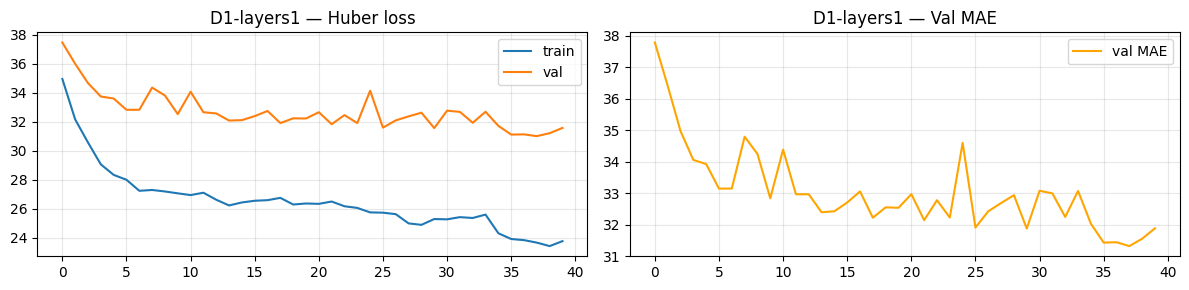


-- num_layers=2 --
  params: 56,641
  ep   5 | train=25.50800 val=38.11713 MAE=38.60186
  ep  10 | train=22.78327 val=30.36397 MAE=30.67185
  ep  15 | train=22.64170 val=31.03813 MAE=31.40532
  ep  20 | train=21.93283 val=30.38422 MAE=30.69461
  ep  25 | train=21.70251 val=29.19830 MAE=29.50634
  ep  29 | train=21.43820 val=29.88316 MAE=30.20553
  -> Early stop at epoch 29


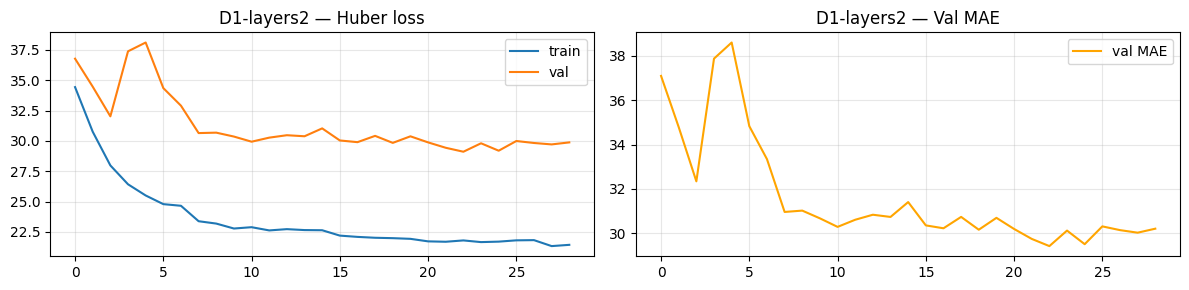


-- num_layers=3 --
  params: 89,921
  ep   5 | train=25.60765 val=32.24191 MAE=32.56321
  ep  10 | train=24.67155 val=36.95044 MAE=37.43924
  ep  15 | train=24.47016 val=32.07356 MAE=32.40285
  ep  20 | train=23.00310 val=31.09675 MAE=31.45704
  ep  22 | train=22.24034 val=30.76162 MAE=31.07457
  -> Early stop at epoch 22


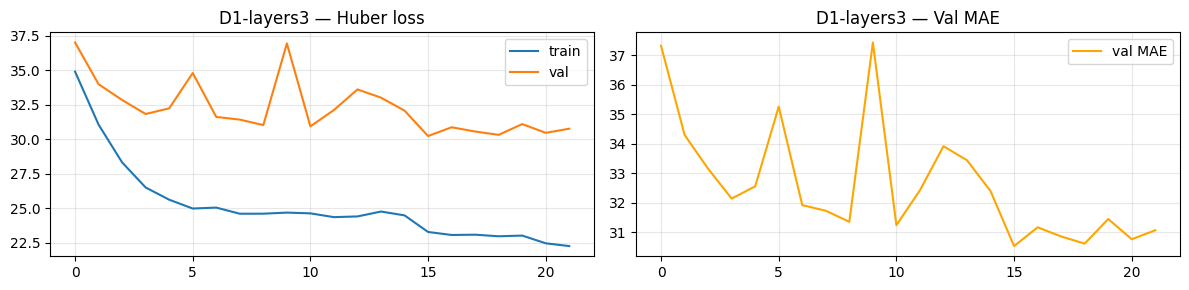

In [ ]:
for n_layers in [1, 2, 3]:
    print(f'\n-- num_layers={n_layers} --')
    torch.manual_seed(seed)
    m = LSTMForecaster(input_size=input_size_best, hidden_size=best_a_hidden,
        num_layers=n_layers, dropout=best_a_dropout).to(device)
    train_d(m, f'D1-layers{n_layers}', f'D1-layers={n_layers}')

In [ ]:
df_d1 = pd.DataFrame(results_log)
df_d1 = df_d1[df_d1['extra'].str.startswith('D1')].sort_values('val_mae')
display(df_d1[['run_id', 'extra', 'val_mae', 'val_rmse', 'epochs_run']])
best_d1_layers = int(df_d1.iloc[0]['extra'].split('=')[-1])
print(f'\n-> Best num_layers: {best_d1_layers}')

,run_id,extra,val_mae,val_rmse,epochs_run
18,D1-layers2,D1-layers=2,29.420172,172.583374,29
19,D1-layers3,D1-layers=3,30.538404,178.329361,22
17,D1-layers1,D1-layers=1,31.315323,183.560471,40



-> Best num_layers: 2


### D1 — LSTM Layers Analysis

| Layers | Parameters | Val MAE | Epochs |
|--------|-----------|---------|--------|
| 1 | 23,361 | 31.32 | 40 |
| **2** | **56,641** | **29.42** | **29** |
| 3 | 106,561 | 30.54 | 22 |



=== D2: Hidden size ===

-- hidden_size=32 --
  params: 16,065
  ep   5 | train=27.18613 val=32.99329 MAE=33.30342
  ep  10 | train=24.82854 val=31.22151 MAE=31.53658
  ep  15 | train=24.69928 val=33.87380 MAE=34.28621
  ep  20 | train=24.69585 val=31.97221 MAE=32.38128
  ep  25 | train=23.15812 val=30.82299 MAE=31.13770
  ep  30 | train=22.42150 val=30.41820 MAE=30.73119
  ep  35 | train=22.17998 val=30.60709 MAE=30.92327
  ep  40 | train=22.12890 val=30.35925 MAE=30.67226


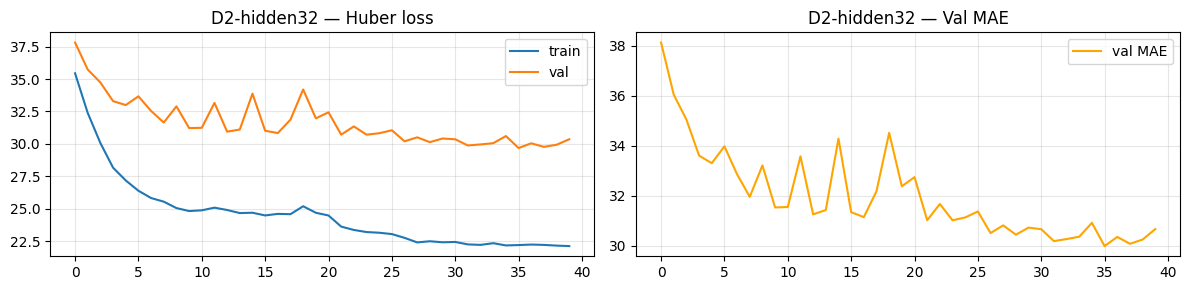


-- hidden_size=64 --
  params: 56,641
  ep   5 | train=25.50800 val=38.11713 MAE=38.60186
  ep  10 | train=22.78327 val=30.36397 MAE=30.67185
  ep  15 | train=22.64170 val=31.03813 MAE=31.40532
  ep  20 | train=21.93283 val=30.38422 MAE=30.69461
  ep  25 | train=21.70251 val=29.19830 MAE=29.50634
  ep  29 | train=21.43820 val=29.88316 MAE=30.20553
  -> Early stop at epoch 29


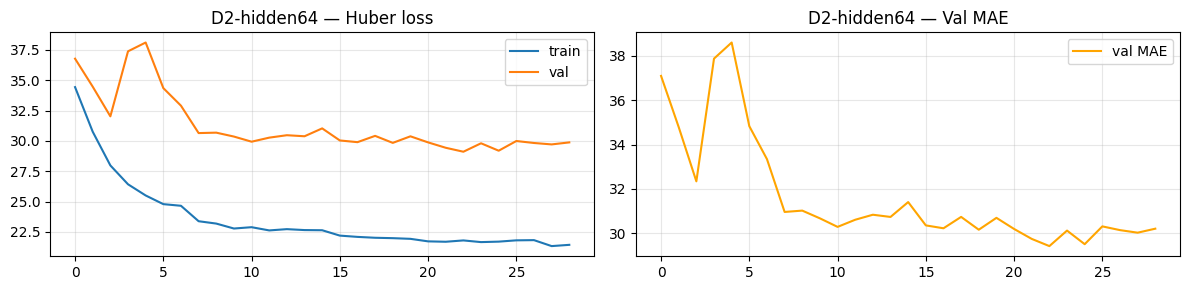


-- hidden_size=128 --
  params: 211,521
  ep   5 | train=23.92841 val=30.76996 MAE=31.09048
  ep  10 | train=23.27090 val=31.30256 MAE=31.78640
  ep  15 | train=21.92239 val=30.65650 MAE=30.96323
  -> Early stop at epoch 15


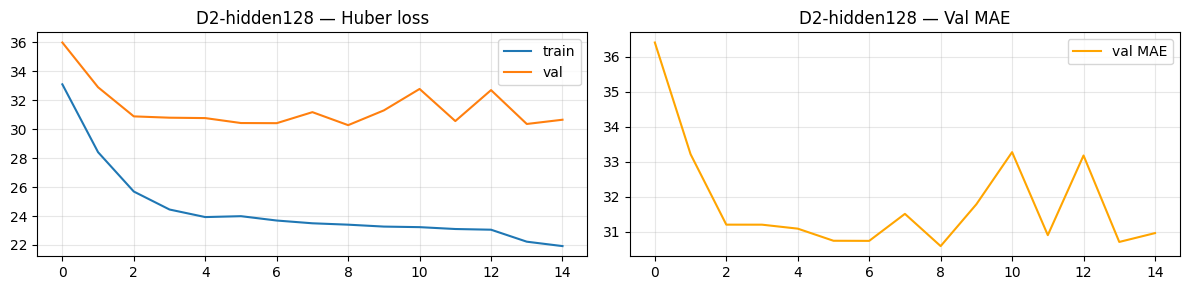

In [ ]:
for hs in [32, 64, 128]:
    print(f'\n-- hidden_size={hs} --')
    torch.manual_seed(seed)
    m = LSTMForecaster(input_size=INPUT_SIZE_BEST, hidden_size=hs,
        num_layers=best_d1_layers, dropout=best_a_dropout).to(device)
    train_d(m, f'D2-hidden{hs}', f'D2-hidden={hs}')

In [ ]:
df_d2 = pd.DataFrame(results_log)
df_d2 = df_d2[df_d2['extra'].str.startswith('D2')].sort_values('val_mae')
display(df_d2[['run_id', 'extra', 'val_mae', 'val_rmse', 'epochs_run']])
best_d2_hidden = int(df_d2.iloc[0]['extra'].split('=')[-1])
print(f'\n-> Best hidden_size: {best_d2_hidden}')

,run_id,extra,val_mae,val_rmse,epochs_run
21,D2-hidden64,D2-hidden=64,29.420172,172.583374,29
20,D2-hidden32,D2-hidden=32,29.993713,178.109940,40
22,D2-hidden128,D2-hidden=128,30.592222,177.829269,15



-> Best hidden_size: 64


### D2 — Hidden Size Analysis

| Hidden Size | Parameters | Val MAE | Epochs |
|-------------|-----------|---------|--------|
| 32 | 16,065 | 30.00 | 40 |
| **64** | **56,641** | **29.42** | **29** |
| 128 | 214,209 | 30.59 | 15 |


=== D3: Dropout ===

-- dropout=0.0 --
  params: 56,641
  ep   5 | train=24.59887 val=31.78488 MAE=32.09983
  ep  10 | train=23.50704 val=33.85528 MAE=34.30912
  ep  13 | train=22.02763 val=32.15856 MAE=32.63126
  -> Early stop at epoch 13


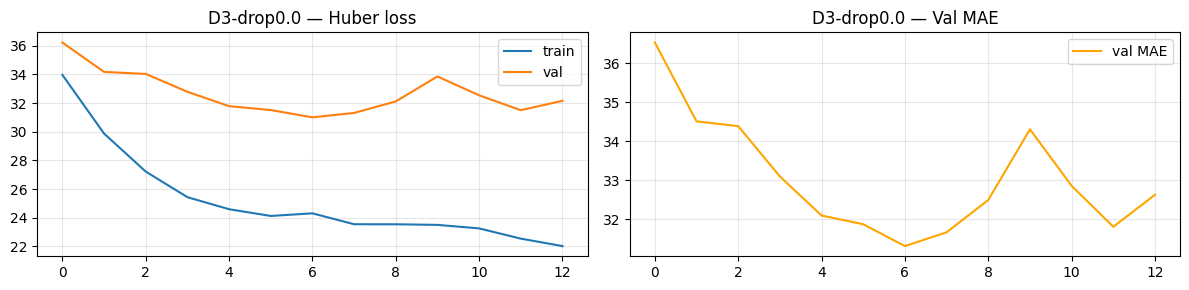


-- dropout=0.2 --
  params: 56,641
  ep   5 | train=25.50800 val=38.11713 MAE=38.60186
  ep  10 | train=22.78327 val=30.36397 MAE=30.67185
  ep  15 | train=22.64170 val=31.03813 MAE=31.40532
  ep  20 | train=21.93283 val=30.38422 MAE=30.69461
  ep  25 | train=21.70251 val=29.19830 MAE=29.50634
  ep  29 | train=21.43820 val=29.88316 MAE=30.20553
  -> Early stop at epoch 29


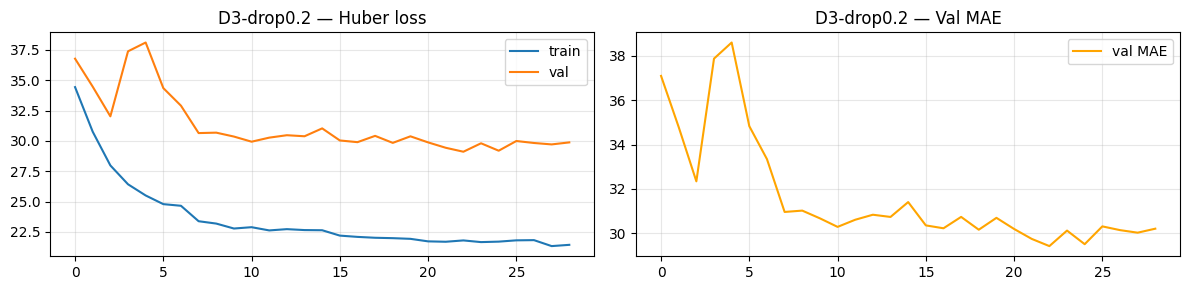


-- dropout=0.5 --
  params: 56,641
  ep   5 | train=27.30693 val=32.66669 MAE=33.03413
  ep  10 | train=24.76453 val=30.91890 MAE=31.23153
  ep  15 | train=24.45868 val=30.75969 MAE=31.06958
  ep  20 | train=23.91430 val=30.76584 MAE=31.07776
  ep  25 | train=23.48898 val=30.42083 MAE=30.73229
  ep  29 | train=23.43654 val=30.53627 MAE=30.84526
  -> Early stop at epoch 29


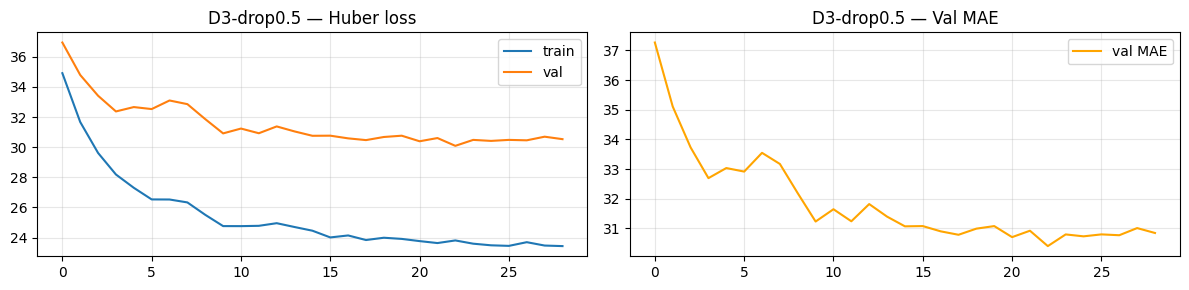

In [ ]:
for drop in [0.0, 0.2, 0.5]:
    print(f'\n-- dropout={drop} --')
    torch.manual_seed(seed)
    m = LSTMForecaster(input_size=input_size_best, hidden_size=best_d2_hidden,
        num_layers=best_d1_layers, dropout=drop).to(device)
    train_d(m, f'D3-drop{drop}', f'D3-dropout={drop}')

In [49]:
df_d3 = pd.DataFrame(results_log)
df_d3 = df_d3[df_d3['extra'].str.startswith('D3')].sort_values('val_mae')
display(df_d3[['run_id', 'extra', 'val_mae', 'val_rmse', 'epochs_run']])
BEST_D3_DROPOUT = float(df_d3.iloc[0]['extra'].split('=')[-1])
print(f'\n-> Best dropout: {BEST_D3_DROPOUT}')

,run_id,extra,val_mae,val_rmse,epochs_run
24,D3-drop0.2,D3-dropout=0.2,29.420172,172.583374,29
25,D3-drop0.5,D3-dropout=0.5,30.403391,178.875244,29
23,D3-drop0.0,D3-dropout=0.0,31.316746,183.387802,13



-> Best dropout: 0.2


### D3 — Dropout Analysis

| Dropout | Val MAE | Epochs |
|---------|---------|--------|
| 0.0 | 31.32 | 13 |
| **0.2** | **29.42** | **29** |
| 0.5 | 30.40 | 29 |

**Winner: dropout = 0.2**

---
## Summary — All Blocks

In [50]:
df_all = pd.DataFrame(results_log)

print('\n== Full experiment log ==')
display(df_all[['run_id', 'block', 'feature_set', 'optimizer', 'lr', 'batch_size',
                'val_mae', 'val_rmse', 'epochs_run', 'extra']]
        .sort_values(['block', 'val_mae'])
        .reset_index(drop=True))

# Best per block
print('\n== Best per block ==')
best_per = (df_all.sort_values('val_mae')
                  .groupby('block', sort=False)
                  .first()
                  .reset_index()
            [['block', 'run_id', 'val_mae', 'val_rmse', 'extra']])
display(best_per)


== Full experiment log ==


,run_id,block,feature_set,optimizer,lr,batch_size,val_mae,val_rmse,epochs_run,extra
0,B2-uncorr,B,set_global_uncorr,Adam,0.0010,128,30.290491,174.800430,31,B2-feature_set
1,B3-support,B,set_global_support,Adam,0.0010,128,30.650831,177.125397,28,B3-feature_set
2,B1-core,B,set_global_core,Adam,0.0010,128,31.202137,182.312332,18,B1-feature_set
3,C1-RMSProp,C,set_global_uncorr,RMSProp,0.0010,128,29.420172,172.583374,29,C1-optimizer
4,C2-lr0.001,C,set_global_uncorr,RMSProp,0.0010,128,29.420172,172.583374,29,C2-lr
5,C3-bs128,C,set_global_uncorr,RMSProp,0.0010,128,29.420172,172.583374,29,C3-batch
6,C4-ReduceOnPlateau,C,set_global_uncorr,RMSProp,0.0010,128,29.420172,172.583374,29,C4-scheduler
7,C5-pat10,C,set_global_uncorr,RMSProp,0.0010,128,29.420172,172.583374,33,C5-patience=10
8,C3-bs64,C,set_global_uncorr,RMSProp,0.0010,64,29.926470,175.551056,27,C3-batch
9,C5-pat5,C,set_global_uncorr,RMSProp,0.0010,128,30.286776,176.203583,16,C5-patience=5



== Best per block ==


,block,run_id,val_mae,val_rmse,extra
0,C,C2-lr0.001,29.420172,172.583374,C2-lr
1,D,D3-drop0.2,29.420172,172.583374,D3-dropout=0.2
2,B,B2-uncorr,30.290491,174.800430,B2-feature_set


In [ ]:
# ── Final best config ─────────────────────────────────────────────────────────
print('== Best configuration found ==')
print(f'  Feature set  : {best_b_feature_set}')
print(f'  Optimizer    : {best_c1_optimizer}')
print(f'  Learning rate: {best_c2_lr}')
print(f'  Batch size   : {best_c3_batch}')
print(f'  Scheduler    : {best_c4_scheduler}')
print(f'  Patience     : {best_c5_patience}')
print(f'  LSTM layers  : {best_d1_layers}')
print(f'  Hidden size  : {best_d2_hidden}')
print(f'  Dropout      : {best_d3_dropout}')

== Best configuration found ==
  Feature set  : set_global_uncorr
  Optimizer    : RMSProp
  Learning rate: 0.001
  Batch size   : 128
  Scheduler    : ReduceOnPlateau
  Patience     : 6
  LSTM layers  : 2
  Hidden size  : 64
  Dropout      : 0.2


### Final Summary

After 26 experiments across Blocks B, C, and D, the optimal LSTM configuration is:

| Parameter | Value | Rationale |
|-----------|-------|----------|
| Feature set | set_global_uncorr (16) | Best signal-to-noise ratio, no redundant features |
| Optimizer | RMSProp | Outperforms Adam for heterogeneous time series |
| Learning rate | 0.001 | Standard default, confirmed optimal |
| Batch size | 128 | Smooth gradients, longer effective training |
| Scheduler | ReduceOnPlateau | Adapts to actual training progress |
| Patience | 6 | Good balance of thoroughness and efficiency |
| LSTM layers | 2 | Two levels of temporal abstraction |
| Hidden size | 64 | Capacity vs generalisation sweet spot |
| Dropout | 0.2 | Light regularisation prevents overfitting |

**Best Val MAE: 29.42 | Best Val RMSE: 172.58**

The high RMSE relative to MAE indicates some large outlier errors — this is expected given 
the heavy-tailed y_target distribution (kurtosis > 50 in the raw data). The model handles 
typical predictions well (MAE around 29) but struggles with extreme values.

A consistent pattern across all experiments: the LSTM converges to its best within 25-30 epochs. 
Under-regularised configurations (no dropout, 3 layers, hidden=128) early-stop much sooner, 
confirming that overfitting — not underfitting — is the primary risk for this data.